# Import Library

In [1]:
# =========================================================
# 1. IMPORT LIBRARY
# =========================================================

!pip install Sastrawi

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import math
import re

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.1 MB/s eta 0:00:00


# Load Model dan Dataset

In [2]:
# =========================================================
# 2. LOAD DATASET
# =========================================================

df = pd.read_csv("/content/drive/MyDrive/MBKM/flask_api/dataset_umkm_bogor.csv")

print("Jumlah dataset:", len(df))

df.head()

Jumlah dataset: 597


,url_produk,nama_produk,kategori,sub_kategori,harga_produk,jumlah_terjual,rating,nama_toko,marketplace,label,nama_produk_clean
0,https://www.tokopedia.com/padifoodie/renginang...,Renginang Khas Bogor Rasa Bawang Terasi dan Ke...,Makanan,Lauk & Bahan Makanan,24000,4,0.0,Padifoodie,tokopedia,0,renginang khas bogor bawang terasi ketan item ...
1,https://www.tokopedia.com/aa-shop90/kopi-cap-t...,Kopi Cap Teko Tanpa Gula Khas Bogor 15sachet,Minuman,Kopi,19250,250,4.9,AA-shop90,tokopedia,1,kopi cap teko gula khas bogor sachet
2,https://www.tokopedia.com/noga-sari/500-gr-nog...,"500 gr - NOGA TENG-TENG KACANG KHAS BOGOR, Car...",Makanan,Camilan & Snack,33500,30,4.5,Noga Sari,tokopedia,1,noga teng teng kacang khas bogor caramel kacang
3,https://www.tokopedia.com/arsyfaqia/manisan-ke...,manisan kelapa kering khas Bogor,Makanan,Camilan & Snack,35000,30,0.0,ArsyfaQia,tokopedia,1,manis kelapa kering khas bogor
4,https://www.tokopedia.com/djadjasnack/enting-e...,Enting-Enting Kacang khas bogor Awet 2-3 Bulan...,Makanan,Camilan & Snack,13400,40,3.0,DJADJASNACK,tokopedia,1,enting enting kacang khas bogor awet


In [3]:
# =========================================================
# 3. LOAD MODEL PRODUCTION
# =========================================================

rf_pipeline = joblib.load("/content/drive/MyDrive/MBKM/flask_api/model_umkm_bogor.joblib")

print("Model Random Forest berhasil dimuat")

Model Random Forest berhasil dimuat


# Setup Text Preprocessing

In [4]:
# =========================================================
# 4. TEXT PREPROCESSING
# =========================================================

stemmer = StemmerFactory().create_stemmer()

stopwords = {
'murah','promo','cod','terlaris','original','ori','asli',
'oleh','pcs','gr','gram','kg','dan','di','ke','dari','yang'
}

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-z\s]', ' ', text)

    words = text.split()

    words = [w for w in words if w not in stopwords]

    return stemmer.stem(' '.join(words))


df['nama_produk_clean'] = df['nama_produk'].apply(clean_text)

# Explorasi Data

        harga_produk  jumlah_terjual      rating
count     597.000000      597.000000  597.000000
mean    61098.527638      661.036851    3.022714
std     70176.731197     4513.413070    2.286228
min      1000.000000        0.000000    0.000000
25%     29990.000000        0.000000    0.000000
50%     44000.000000       10.000000    4.600000
75%     60000.000000       98.000000    4.900000
max    615440.000000    57300.000000    5.000000


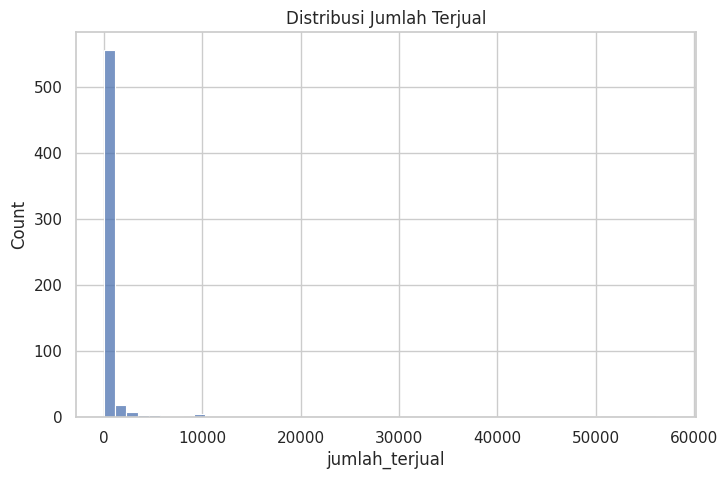

In [5]:
# =========================================================
# 5. EXPLORATORY DATA ANALYSIS
# =========================================================

print(df[['harga_produk','jumlah_terjual','rating']].describe())

plt.figure(figsize=(8,5))
sns.histplot(df['jumlah_terjual'], bins=50)

plt.title("Distribusi Jumlah Terjual")
plt.show()

# Dynamic Labeling

In [6]:
# =========================================================
# 6. DYNAMIC LABELING
# =========================================================

median_terjual = df['jumlah_terjual'].median()

df['label'] = (df['jumlah_terjual'] > median_terjual).astype(int)

print("Median jumlah terjual:", median_terjual)

Median jumlah terjual: 10.0


# Feature Engineering


In [7]:
# =========================================================
# 7. FEATURE ENGINEERING
# =========================================================

text_feature = 'nama_produk_clean'

cat_features = ['kategori','sub_kategori']

num_features = ['harga_produk','rating']

preprocessor = ColumnTransformer(
    transformers=[
        ('text',TfidfVectorizer(max_features=1000),text_feature),
        ('cat',OneHotEncoder(handle_unknown='ignore'),cat_features),
        ('num',StandardScaler(),num_features)
    ]
)

# Split Dataset

In [8]:
# =========================================================
# 8. SPLIT DATASET
# =========================================================

X = df[[text_feature] + cat_features + num_features]

y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

# Training Logistic Regression

In [9]:
# =========================================================
# 9. TRAIN LOGISTIC REGRESSION
# =========================================================

lr_pipeline = Pipeline([
('preprocessor',preprocessor),
('classifier',LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=1000),
                                                  'nama_produk_clean'),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['kategori', 'sub_kategori']),
                                                 ('num', StandardScaler(),
                                                  ['harga_produk',
                                                   'rating'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

# Evaluasi Model LR

In [10]:
# =========================================================
# 10. EVALUASI LOGISTIC REGRESSION
# =========================================================

y_pred_lr = lr_pipeline.predict(X_test)

y_proba_lr = lr_pipeline.predict_proba(X_test)[:,1]

print("Accuracy:",accuracy_score(y_test,y_pred_lr))

print("ROC AUC:",roc_auc_score(y_test,y_proba_lr))

print(classification_report(y_test,y_pred_lr))

Accuracy: 0.7916666666666666
ROC AUC: 0.8713531536537927
              precision    recall  f1-score   support

           0       0.88      0.69      0.77        61
           1       0.74      0.90      0.81        59

    accuracy                           0.79       120
   macro avg       0.81      0.79      0.79       120
weighted avg       0.81      0.79      0.79       120



# Evaluasi Model RF

In [11]:
# =========================================================
# 11. EVALUASI RANDOM FOREST
# =========================================================

y_pred_rf = rf_pipeline.predict(X_test)

y_proba_rf = rf_pipeline.predict_proba(X_test)[:,1]

print("Accuracy:",accuracy_score(y_test,y_pred_rf))

print("ROC AUC:",roc_auc_score(y_test,y_proba_rf))

print(classification_report(y_test,y_pred_rf))

Accuracy: 0.85
ROC AUC: 0.9315087524312309
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        61
           1       0.87      0.81      0.84        59

    accuracy                           0.85       120
   macro avg       0.85      0.85      0.85       120
weighted avg       0.85      0.85      0.85       120



# Confusional Matriks Manual dan Image

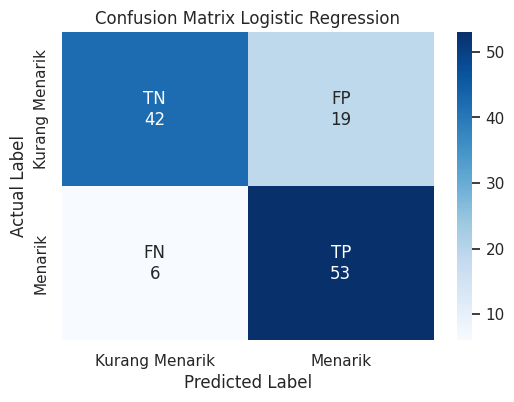

In [12]:
# =========================================================
# CONFUSION MATRIX LOGISTIC REGRESSION - VISUAL DETAIL
# =========================================================

cm_lr = confusion_matrix(y_test, y_pred_lr)

TN, FP, FN, TP = cm_lr.ravel()

labels = np.array([
    ["TN\n"+str(TN), "FP\n"+str(FP)],
    ["FN\n"+str(FN), "TP\n"+str(TP)]
])

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=labels,
    fmt='',
    cmap='Blues',
    xticklabels=['Kurang Menarik','Menarik'],
    yticklabels=['Kurang Menarik','Menarik']
)

plt.title("Confusion Matrix Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [13]:
# =========================================================
# CONFUSION MATRIX LOGISTIC REGRESSION - MANUAL
# =========================================================

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix Logistic Regression")
print(cm_lr)

TN_lr, FP_lr, FN_lr, TP_lr = cm_lr.ravel()

print("\nDetail Matriks:")
print("True Negative (TN):", TN_lr)
print("False Positive (FP):", FP_lr)
print("False Negative (FN):", FN_lr)
print("True Positive (TP):", TP_lr)

accuracy_lr = (TP_lr + TN_lr) / (TP_lr + TN_lr + FP_lr + FN_lr)

precision_lr = TP_lr / (TP_lr + FP_lr) if (TP_lr + FP_lr) != 0 else 0

recall_lr = TP_lr / (TP_lr + FN_lr) if (TP_lr + FN_lr) != 0 else 0

f1_lr = 2 * (precision_lr * recall_lr) / (precision_lr + recall_lr) if (precision_lr + recall_lr) != 0 else 0

print("\n=== PERHITUNGAN METRIK MANUAL ===")

print("Accuracy :", round(accuracy_lr,4))
print("Precision :", round(precision_lr,4))
print("Recall :", round(recall_lr,4))
print("F1 Score :", round(f1_lr,4))

Confusion Matrix Logistic Regression
[[42 19]
 [ 6 53]]

Detail Matriks:
True Negative (TN): 42
False Positive (FP): 19
False Negative (FN): 6
True Positive (TP): 53

=== PERHITUNGAN METRIK MANUAL ===
Accuracy : 0.7917
Precision : 0.7361
Recall : 0.8983
F1 Score : 0.8092


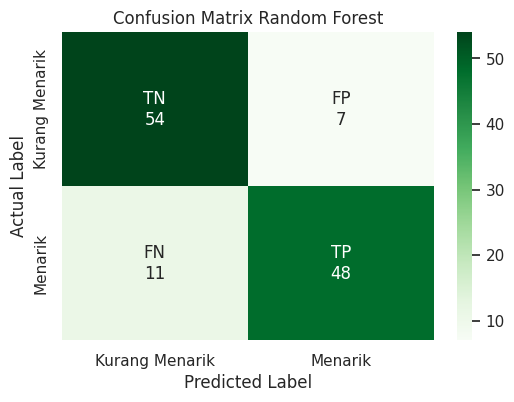

In [14]:
# =========================================================
# CONFUSION MATRIX RANDOM FOREST - VISUAL DETAIL
# =========================================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

TN, FP, FN, TP = cm_rf.ravel()

labels = np.array([
    ["TN\n"+str(TN), "FP\n"+str(FP)],
    ["FN\n"+str(FN), "TP\n"+str(TP)]
])

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=labels,
    fmt='',
    cmap='Greens',
    xticklabels=['Kurang Menarik','Menarik'],
    yticklabels=['Kurang Menarik','Menarik']
)

plt.title("Confusion Matrix Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [15]:
# =========================================================
# CONFUSION MATRIX RANDOM FOREST - PERHITUNGAN MANUAL
# =========================================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix Random Forest")
print(cm_rf)

# Ekstrak nilai matriks
TN_rf, FP_rf, FN_rf, TP_rf = cm_rf.ravel()

print("\nDetail Matriks:")
print("True Negative (TN):", TN_rf)
print("False Positive (FP):", FP_rf)
print("False Negative (FN):", FN_rf)
print("True Positive (TP):", TP_rf)

# Perhitungan manual
accuracy_rf = (TP_rf + TN_rf) / (TP_rf + TN_rf + FP_rf + FN_rf)

precision_rf = TP_rf / (TP_rf + FP_rf) if (TP_rf + FP_rf) != 0 else 0

recall_rf = TP_rf / (TP_rf + FN_rf) if (TP_rf + FN_rf) != 0 else 0

f1_rf = 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf) if (precision_rf + recall_rf) != 0 else 0

print("\n=== PERHITUNGAN METRIK MANUAL ===")

print("Accuracy :", round(accuracy_rf,4))
print("Precision :", round(precision_rf,4))
print("Recall :", round(recall_rf,4))
print("F1 Score :", round(f1_rf,4))

# Verifikasi dengan sklearn
print("\n=== VERIFIKASI DENGAN SKLEARN ===")

print("Accuracy sklearn :", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Confusion Matrix Random Forest
[[54  7]
 [11 48]]

Detail Matriks:
True Negative (TN): 54
False Positive (FP): 7
False Negative (FN): 11
True Positive (TP): 48

=== PERHITUNGAN METRIK MANUAL ===
Accuracy : 0.85
Precision : 0.8727
Recall : 0.8136
F1 Score : 0.8421

=== VERIFIKASI DENGAN SKLEARN ===
Accuracy sklearn : 0.85
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        61
           1       0.87      0.81      0.84        59

    accuracy                           0.85       120
   macro avg       0.85      0.85      0.85       120
weighted avg       0.85      0.85      0.85       120



# ROC Curve Perbandingan Model

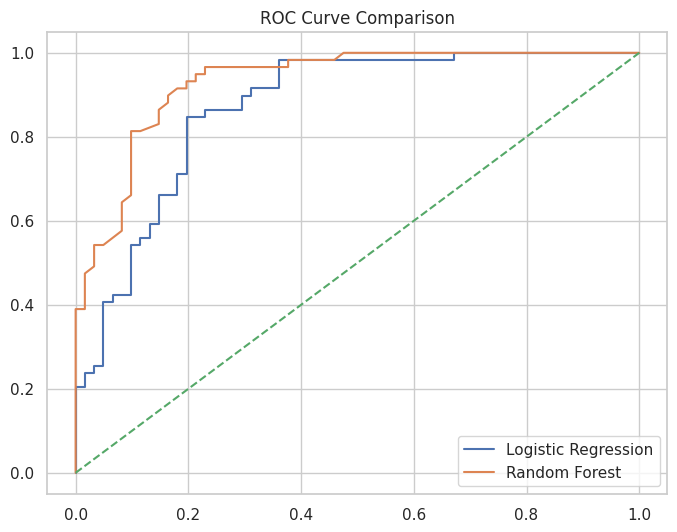

In [16]:
# =========================================================
# 13. ROC CURVE
# =========================================================

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")

plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# TF IDF Model Production (RF)

In [17]:
# =========================================================
# 14. TF-IDF MATRIX
# =========================================================

tfidf_vectorizer = rf_pipeline.named_steps['preprocessor'].transformers_[0][1]

X_text = tfidf_vectorizer.transform(df['nama_produk_clean'])

print("Shape TF-IDF :", X_text.shape)


Shape TF-IDF : (597, 726)


# Feature Importance

In [18]:
# =========================================================
# 15. FEATURE IMPORTANCE RANDOM FOREST
# =========================================================

rf_model = rf_pipeline.named_steps['classifier']

tfidf_features = rf_pipeline.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out()

cat_features_names = rf_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(['kategori','sub_kategori'])

all_features = np.concatenate([tfidf_features, cat_features_names, ['harga_produk','rating']])

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
743,rating,0.231107
742,harga_produk,0.052349
79,bogor,0.040656
323,khas,0.022942
302,kaos,0.020820
731,sub_kategori_Atasan & Pakaian Kasual,0.018020
297,kacang,0.012960
729,kategori_Pakaian & Fashion,0.012726
642,talas,0.010820
234,golden,0.009875


In [19]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=feature_importance_df)

https://docs.google.com/spreadsheets/d/1pS_smNkpoL4AtBxbvfapT4me1aBLZkrdk0xG7asgh4c/edit#gid=0


/tmp/ipykernel_467/456753651.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


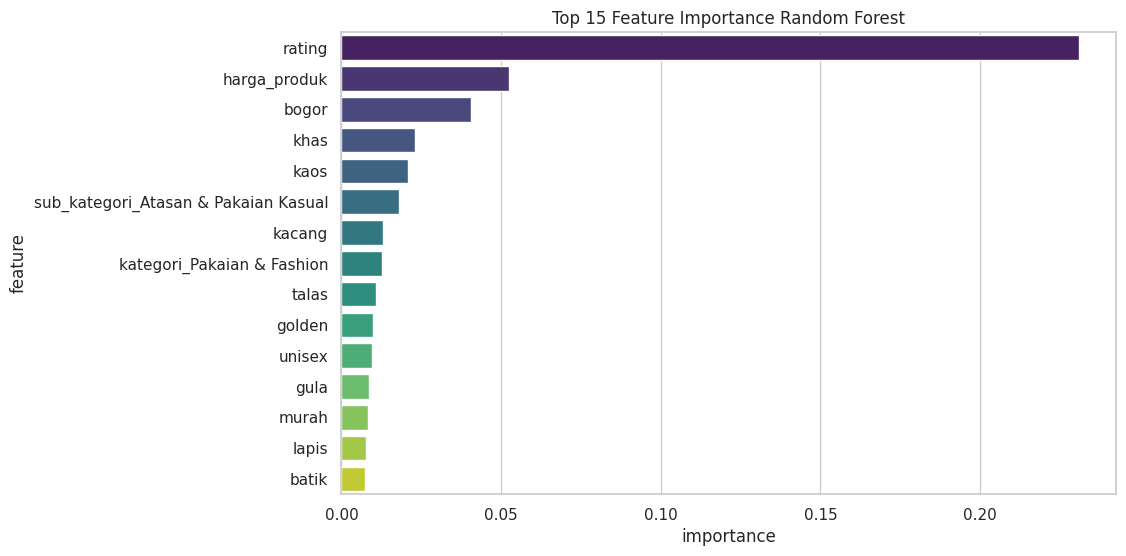

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="importance",
    y="feature",
    data=feature_importance_df.head(15),
    palette="viridis"
)

plt.title("Top 15 Feature Importance Random Forest")

plt.show()

In [22]:
# =========================================================
# 16. PERHITUNGAN TF MANUAL
# =========================================================

doc = df.iloc[0]['nama_produk_clean']

tokens = doc.split()

total_words = len(tokens)

tf_dict = {}

for word in tokens:

    tf_dict[word] = tokens.count(word) / total_words

tf_df = pd.DataFrame({
    "kata": tf_dict.keys(),
    "TF": tf_dict.values()
})

tf_df

,kata,TF
0,renginang,0.071429
1,khas,0.142857
2,bogor,0.142857
3,rasa,0.142857
4,bawang,0.071429
5,terasi,0.071429
6,ketan,0.071429
7,item,0.071429
8,cita,0.071429
9,unik,0.071429


TF(t,d)=
∑f(t,d)
f(t,d)


In [23]:
# =========================================================
# 17. PERHITUNGAN IDF MANUAL
# =========================================================

N = len(df)

idf_dict = {}

for word in tf_dict.keys():

    df_count = df['nama_produk_clean'].str.contains(word).sum()

    idf = np.log((N+1)/(df_count+1)) + 1

    idf_dict[word] = idf

idf_df = pd.DataFrame({
    "kata": idf_dict.keys(),
    "IDF": idf_dict.values()
})

idf_df

,kata,IDF
0,renginang,6.700444
1,khas,2.110387
2,bogor,1.039221
3,rasa,4.135494
4,bawang,6.007296
5,terasi,6.294978
6,ketan,3.867230
7,item,6.700444
8,cita,6.700444
9,unik,6.700444


IDF(t)=log(df+1N+1​)+1

In [24]:
# =========================================================
# 18. TF-IDF MANUAL
# =========================================================

tfidf_manual_df = tf_df.merge(idf_df, on="kata")

tfidf_manual_df["TF_IDF_manual"] = tfidf_manual_df["TF"] * tfidf_manual_df["IDF"]

tfidf_manual_df

,kata,TF,IDF,TF_IDF_manual
0,renginang,0.071429,6.700444,0.478603
1,khas,0.142857,2.110387,0.301484
2,bogor,0.142857,1.039221,0.148460
3,rasa,0.142857,4.135494,0.590785
4,bawang,0.071429,6.007296,0.429093
5,terasi,0.071429,6.294978,0.449641
6,ketan,0.071429,3.867230,0.276231
7,item,0.071429,6.700444,0.478603
8,cita,0.071429,6.700444,0.478603
9,unik,0.071429,6.700444,0.478603


In [25]:
# =========================================================
# 19. VALIDASI TF-IDF DENGAN MODEL
# =========================================================

feature_names = tfidf_vectorizer.get_feature_names_out()

vector = X_text[0].toarray()[0]

tfidf_model_df = pd.DataFrame({
    "kata": feature_names,
    "TF_IDF_model": vector
})

tfidf_model_df = tfidf_model_df[tfidf_model_df["TF_IDF_model"] > 0]

tfidf_model_df.head(10)

,kata,TF_IDF_model
53,bawang,0.323934
79,bogor,0.117057
128,cita,0.362758
275,item,0.362758
320,ketan,0.223574
323,khas,0.240372
469,otentik,0.362758
556,renginang,0.362758
660,terasi,0.340047
695,unik,0.362758


In [26]:
# =========================================================
# 20. COSINE SIMILARITY
# =========================================================

query = "lapis talas bogor"

query_vec = tfidf_vectorizer.transform([query])

similarities = cosine_similarity(query_vec, X_text).flatten()

top_idx = similarities.argsort()[-5:][::-1]

hasil_similarity = df.iloc[top_idx][['nama_produk','harga_produk','jumlah_terjual','rating']]

hasil_similarity["similarity_score"] = similarities[top_idx]

hasil_similarity

,nama_produk,harga_produk,jumlah_terjual,rating,similarity_score
309,Lapis Talas Bogor Sangkuriang Original,44000,696,4.9,0.787247
285,Lapis Talas Bogor Sangkuriang,44000,3000,4.9,0.787247
348,Lapis Talas Bogor Sangkuriang Full Talas,44000,157,4.9,0.707937
334,Lapis Bogor Sangkuriang FULL TALAS KEJU | Lapi...,40000,1,0.0,0.702554
283,ALL VARIANT Lapis Talas Bogor Sangkuriang | La...,40000,52,4.6,0.687034


In [27]:
# =========================================================
# 21. COSINE SIMILARITY MANUAL
# =========================================================

vec_A = X_text[top_idx[0]].toarray()[0]
vec_B = X_text[top_idx[1]].toarray()[0]

dot = np.dot(vec_A, vec_B)

normA = np.linalg.norm(vec_A)
normB = np.linalg.norm(vec_B)

cosine_manual = dot / (normA * normB)

cosine_model = cosine_similarity([vec_A],[vec_B])[0][0]

print("Dot product:", dot)

print("Norm A:", normA)
print("Norm B:", normB)

print("Cosine manual:", cosine_manual)

print("Cosine sklearn:", cosine_model)

Dot product: 1.0
Norm A: 1.0
Norm B: 1.0
Cosine manual: 1.0
Cosine sklearn: 1.0


cos(θ)=∣∣A∣∣∣∣B∣∣A⋅B​

In [28]:
# =========================================================
# 22. LOGISTIC REGRESSION MANUAL
# =========================================================

sample = X_test.iloc[0:1]

sample_trans = lr_pipeline.named_steps['preprocessor'].transform(sample)

lr_model = lr_pipeline.named_steps['classifier']

bias = lr_model.intercept_[0]

coef = lr_model.coef_[0]

z = bias + np.dot(sample_trans.toarray()[0], coef)

prob = 1/(1+math.exp(-z))

print("Bias:", bias)

print("Z value:", z)

print("Sigmoid probability:", prob)

print("Model probability:", lr_model.predict_proba(sample_trans)[0][1])

Bias: 0.10172397935778989
Z value: 1.3709313073909266
Sigmoid probability: 0.7975305786172665
Model probability: 0.7975305786172665


P=1+e−z1​

In [29]:
# =========================================================
# 23. RANDOM FOREST VOTING
# =========================================================

sample_trans = rf_pipeline.named_steps['preprocessor'].transform(sample)

rf_model = rf_pipeline.named_steps['classifier']

votes = [tree.predict(sample_trans)[0] for tree in rf_model.estimators_]

vote1 = sum(votes)
vote0 = len(votes) - vote1

prob_manual = vote1 / len(votes)

print("Total trees:", len(votes))

print("Vote kelas 1:", vote1)

print("Vote kelas 0:", vote0)

print("Prob manual:", prob_manual)

print("Prob model:", rf_model.predict_proba(sample_trans)[0][1])

Total trees: 200
Vote kelas 1: 161.0
Vote kelas 0: 39.0
Prob manual: 0.805
Prob model: 0.805


In [30]:
# =========================================================
# 24. PERBANDINGAN MODEL
# =========================================================

comparison_df = pd.DataFrame({

    "Model":["Logistic Regression","Random Forest"],

    "Accuracy":[accuracy_lr, accuracy_rf],

    "Precision":[precision_lr, precision_rf],

    "Recall":[recall_lr, recall_rf],

    "F1 Score":[f1_lr, f1_rf],

    "ROC AUC":[roc_auc_score(y_test,y_proba_lr),
               roc_auc_score(y_test,y_proba_rf)]

})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.791667,0.736111,0.898305,0.809160,0.871353
1,Random Forest,0.850000,0.872727,0.813559,0.842105,0.931509
